In [110]:
import pandas as pd
import pyterrier as pt
from ir_measures import *
import matplotlib.pyplot as plt
import seaborn as sns
import math
import textwrap

if not pt.started():
    pt.init()

/tmp/ipykernel_499/909422409.py:9: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


In [2]:
ohsumed_docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

def _sens_docs(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, ohsumed_docs, left_on = "doc_id", right_on = "docno")
    return merged.sensitivity.sum()
    
import ir_measures
sens_docs = ir_measures.define_byquery(
    _sens_docs, 
    name="sens_docs")

def calculate_csdcg_10(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, qrels, on = "doc_id", how = "left").fillna(0).head(10)
    merged = pd.merge(merged, ohsumed_docs, left_on = "doc_id", right_on = "docno")
    # print(merged[["relevance", "sensitivity"]])
    csdcg = 0
    for rank, doc in enumerate(merged.iterrows()):
        relevance = int(doc[1].relevance)
        sensitivity = int(doc[1]["sensitivity"])
        up = (2 ** relevance) - 1
        low = math.log(rank + 2)
        penalty = 12 if sensitivity == 1 else 0
        csdcg += ((up / low) - penalty)
    return csdcg

def _ncsdcg_cut_10(qrels, run):    
    # Calculate query csdcg
    query_csdcg = calculate_csdcg_10(qrels, run)
    
    # Calculate best csdcg
    merged_qrels = pd.merge(qrels, ohsumed_docs, left_on = "doc_id", right_on = "docno").drop(columns = ["title", "abstract", "text", "t5_sensitivity", "docno"])
    best_qrels =  merged_qrels.sort_values(by=['sensitivity', 'relevance'], ascending=[True, False])
    best_qrels = best_qrels.drop(columns = ["relevance", "sensitivity"])
    best_csdcg = calculate_csdcg_10(qrels, best_qrels)
    
    # Calculate worst csdcg
    worst_qrels =  merged_qrels.sort_values(by=['sensitivity', 'relevance'], ascending=[False, True])
    worst_qrels = worst_qrels.drop(columns = ["relevance", "sensitivity"])
    worst_csdcg = calculate_csdcg_10(qrels, worst_qrels)
    
    if query_csdcg <= worst_csdcg:
        query_csdcg = 0
        
    normalised_csdcg = (query_csdcg - worst_csdcg) / (best_csdcg - worst_csdcg)

    assert normalised_csdcg >= 0
    assert normalised_csdcg <= 1
    
    return normalised_csdcg
    
import ir_measures
nCSDCG_cut_10 = ir_measures.define_byquery(
    _ncsdcg_cut_10, 
    name="nCSDCG_cut_10")


In [106]:
first_stages = [
    pt.io.read_results("../runs/bm25 % 100"),
    pt.io.read_results("../runs/splade_relevance % 100"),
    pt.io.read_results("../runs/splade_sans % 100"),
    pt.io.read_results("../runs/splade_distil % 100")
]

second_stages = [
    pt.io.read_results("../runs/intermediates/bm25 % 100 >> filter % 100"),
    pt.io.read_results("../runs/intermediates/splade_relevance % 100 >> filter % 100"),
    pt.io.read_results("../runs/intermediates/splade_sans % 100 >> filter % 100"),
    pt.io.read_results("../runs/intermediates/splade_distil % 100 >> filter % 100"),
]

third_stages = [
    pt.io.read_results("../runs/intermediates/bm25 % 100 >> filter % 100 >> get_text >> monot5_relevance"),
    pt.io.read_results("../runs/intermediates/splade_relevance % 100 >> filter % 100 >> get_text >> monot5_relevance"),
    pt.io.read_results("../runs/intermediates/splade_sans % 100 >> filter % 100 >> get_text >> monot5_relevance"),
    pt.io.read_results("../runs/intermediates/splade_distil % 100 >> filter % 100 >> get_text >> monot5_relevance"),
]

# third_stages = [
#     pt.io.read_results("../runs/intermediates/bm25 % 100 >> filter % 100 >> get_text >> monot5_sans"),
#     pt.io.read_results("../runs/intermediates/splade_relevance % 100 >> filter % 100 >> get_text >> monot5_sans"),
#     pt.io.read_results("../runs/intermediates/splade_sans % 100 >> filter % 100 >> get_text >> monot5_sans"),
#     pt.io.read_results("../runs/intermediates/splade_distil % 100 >> filter % 100 >> get_text >> monot5_sans"),
# ]

first_stage_names = [
    "BM25",
    "SPLADE Relevance",
    "SPLADE SANS",
    "SPLADE Distil"
]

second_stage_names = [
    "BM25 >> Filter",
    "SPLADE Relevance >> Filter",
    "SPLADE SANS >> Filter",
    "SPLADE Distil >> Filter"
]

third_stage_names = [
    "BM25 >> Filter >> monoT5",
    "SPLADE Relevance >> Filter >> monoT5",
    "SPLADE SANS >> Filter >> monoT5",
    "SPLADE Distil >> Filter >> monoT5"
]

# third_stage_names = [
#     "BM25 >> Filter >> monoT5 (SANS)",
#     "SPLADE Relevance >> Filter >> monoT5 (SANS)",
#     "SPLADE SANS >> Filter >> monoT5 (SANS)",
#     "SPLADE Distil >> Filter >> monoT5 (SANS)"
# ]

all_stages = first_stages + second_stages + third_stages
all_names = first_stage_names + second_stage_names + third_stage_names

In [107]:
exp = pt.Experiment(
    all_stages,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10, nCSDCG_cut_10],
    names = all_names,
    round = 4
)

In [108]:
exp

,name,nDCG@10,sens_docs@10,nCSDCG_cut_10
0,BM25,0.3917,1.3396,0.7077
1,SPLADE Relevance,0.4375,1.2170,0.7276
2,SPLADE SANS,0.4557,0.8302,0.7848
3,SPLADE Distil,0.2841,0.2736,0.7983
4,BM25 >> Filter,0.3839,1.1698,0.7250
5,SPLADE Relevance >> Filter,0.4289,1.0283,0.7462
6,SPLADE SANS >> Filter,0.4461,0.7925,0.7869
7,SPLADE Distil >> Filter,0.2833,0.2170,0.8033
8,BM25 >> Filter >> monoT5,0.4706,1.2453,0.7327
9,SPLADE Relevance >> Filter >> monoT5,0.4802,1.1981,0.7618


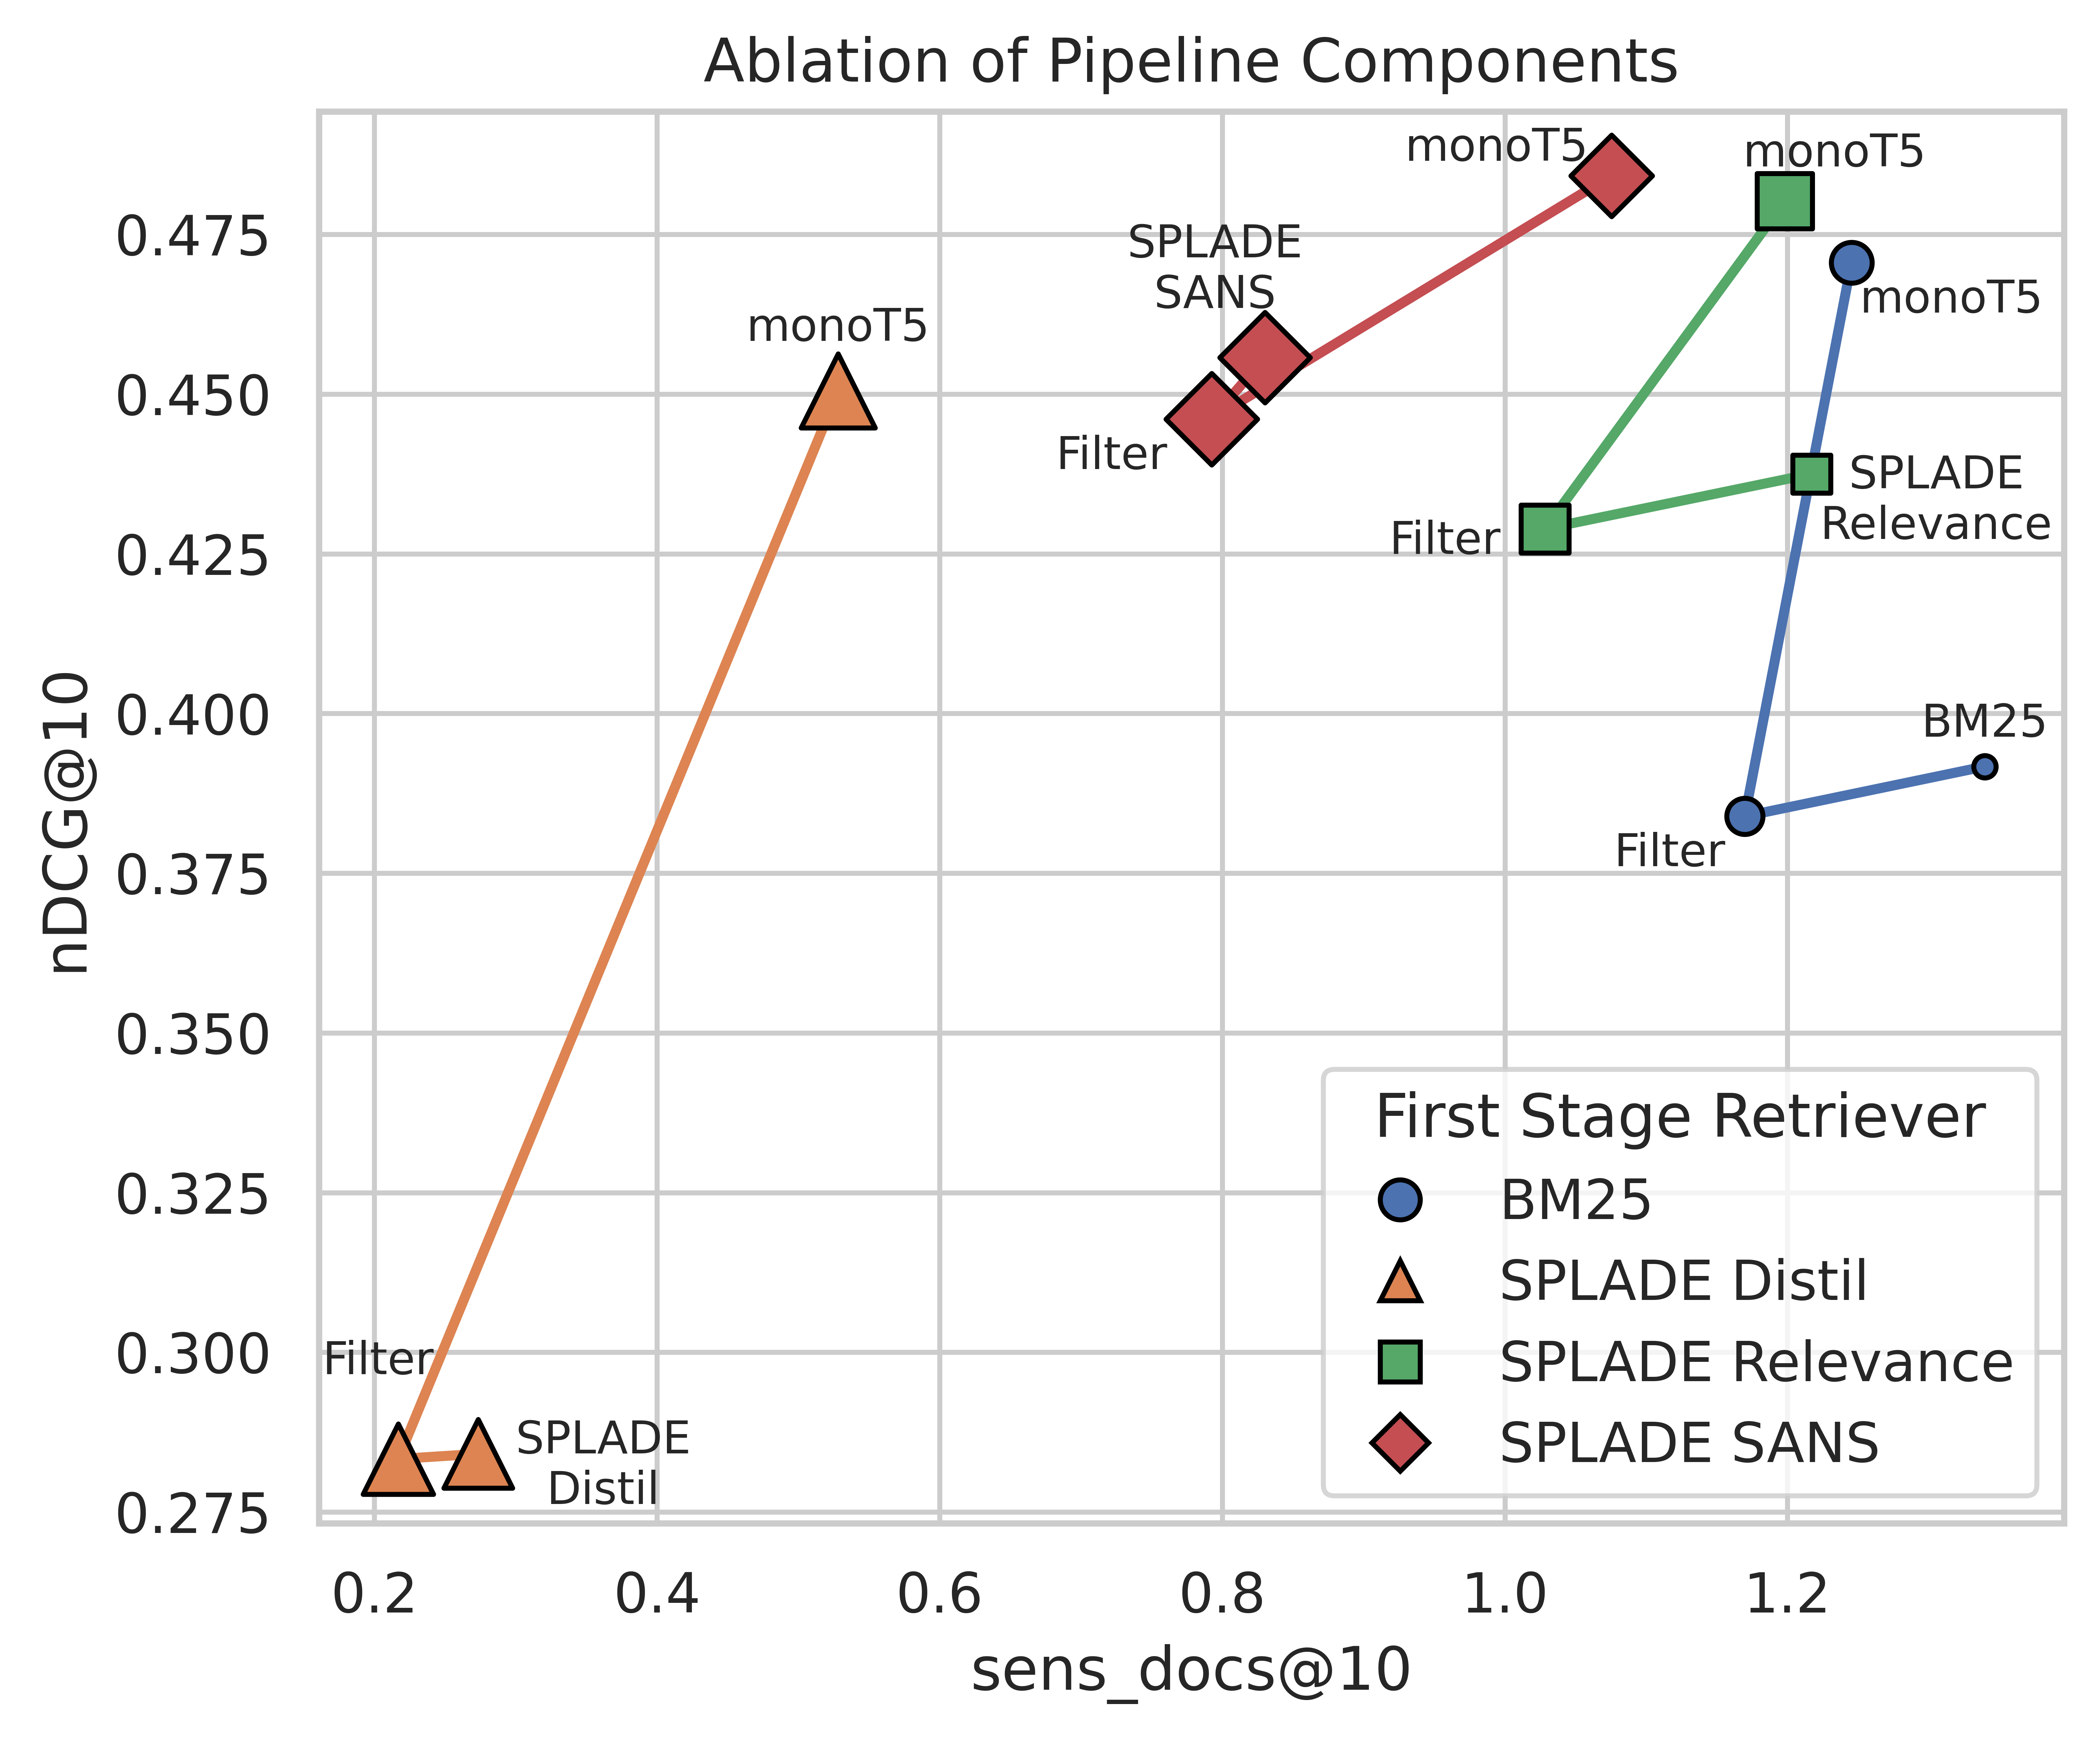

In [169]:
from matplotlib.lines import Line2D

# Extract base system
exp['base'] = exp['name'].str.extract(r'^(BM25|SPLADE Relevance|SPLADE SANS|SPLADE Distil)')
exp['score_normalised'] =  (exp['nCSDCG_cut_10'] - exp['nCSDCG_cut_10'].min()) / (exp['nCSDCG_cut_10'].max() - exp['nCSDCG_cut_10'].min()) + 0.1
exp["marker_size"] = 200 * exp["score_normalised"]
exp["added"] = exp["name"].apply(lambda x : x.split(">>")[-1])

# Define unique markers
markers = {
    'BM25': 'o',
    'SPLADE Relevance': 's',
    'SPLADE SANS': 'D',
    'SPLADE Distil': '^'
}

#(lr,ud)
exp['offset'] = [
    (0, 6),     # BM25
    (25, -13),    # SPLADE Relevance
    (-10, 10),    # SPLADE SANS
    (25, -10),   # SPLADE Distil
    (-15, -10),     # BM25 >> Filter
    (-20, -5),    # SPLADE Relevance >> Filter
    (-20, -10),    # SPLADE SANS >> Filter
    (-4, 17),    # SPLADE Distil >> Filter
    (20, -10),  # BM25 >> Filter >> monoT5
    (10, 7),     # SPLADE Relevance >> Filter >> monoT5
    (-23, 3),     # SPLADE SANS >> Filter >> monoT5
    (0, 10),      # SPLADE Distil >> Filter >> monoT5
]

# Plot
plt.figure(figsize=(6, 5), dpi = 1080)
sns.set(style="whitegrid")

for base, group in exp.groupby('base'):
    group_sorted = group.sort_values(by='name')
    
    plt.plot(group_sorted['sens_docs@10'], group_sorted['nDCG@10'],
             label=base,
             marker=markers.get(base, 'o'),
             linestyle='-',
             linewidth=2,
             markersize = 0
             )

    texts = []
    # Plot each point individually with size based on nCSDCG
    for _, row in group_sorted.iterrows():
        plt.scatter(row['sens_docs@10'], row['nDCG@10'],
                    s=row['marker_size'],
                    color=plt.gca().lines[-1].get_color(),
                    marker=markers.get(base, 'o'),
                    edgecolors='black',
                    zorder=3)
        
    
        plt.annotate(
            '\n'.join(textwrap.wrap(str(row['added']), width=5, break_long_words=False)),
            xy=(row['sens_docs@10'], row['nDCG@10']),
            fontsize=9,
            xytext=row['offset'],                # 10 points above
            textcoords='offset points',
            ha='center'
        )


# Get the color for each base from the plotted lines
legend_handles = []
for base, group in exp.groupby('base'):
    color = plt.gca().lines[len(legend_handles)].get_color()  # get color in order of plotting
    handle = Line2D([0], [0], marker=markers[base], color=color, label=base,
                    linestyle='None', markersize=8, markerfacecolor=color, markeredgecolor='black')
    legend_handles.append(handle)



# Labels and formatting
plt.xlabel("sens_docs@10")
plt.ylabel("nDCG@10")
plt.title("Ablation of Pipeline Components")
# plt.legend(title="First Stage Retriever")
plt.legend(handles=legend_handles, title="First Stage Retriever", loc='best')
plt.tight_layout()
plt.savefig("ablation_of_pipeline_components.png", dpi = 1080)
# plt.show()

In [158]:
exp

,name,nDCG@10,sens_docs@10,nCSDCG_cut_10,base,score_normalised,marker_size,added,offset
0,BM25,0.3917,1.3396,0.7077,BM25,-1.000000,-200.000000,BM25,"(0, 6)"
1,SPLADE Relevance,0.4375,1.2170,0.7276,SPLADE Relevance,-0.628385,-125.676937,SPLADE Relevance,"(25, -13)"
2,SPLADE SANS,0.4557,0.8302,0.7848,SPLADE SANS,0.439776,87.955182,SPLADE SANS,"(-10, 10)"
3,SPLADE Distil,0.2841,0.2736,0.7983,SPLADE Distil,0.691877,138.375350,SPLADE Distil,"(25, -10)"
4,BM25 >> Filter,0.3839,1.1698,0.7250,BM25,-0.676937,-135.387488,Filter,"(-15, -10)"
5,SPLADE Relevance >> Filter,0.4289,1.0283,0.7462,SPLADE Relevance,-0.281046,-56.209150,Filter,"(-20, -5)"
6,SPLADE SANS >> Filter,0.4461,0.7925,0.7869,SPLADE SANS,0.478992,95.798319,Filter,"(-20, -10)"
7,SPLADE Distil >> Filter,0.2833,0.2170,0.8033,SPLADE Distil,0.785247,157.049486,Filter,"(-4, 17)"
8,BM25 >> Filter >> monoT5,0.4706,1.2453,0.7327,BM25,-0.533147,-106.629318,monoT5,"(20, -10)"
9,SPLADE Relevance >> Filter >> monoT5,0.4802,1.1981,0.7618,SPLADE Relevance,0.010271,2.054155,monoT5,"(10, 7)"
